# Pet Finder - Adopción de Mascotas

PetFinder.es una plataforma de adopción de Mascotas de Malasia, con una base de datos de más de 150.000 animales. 

Las tasas de adopción de animales están fuertemente correlacionadas con los metadatos asociados con sus perfiles en línea, como el texto descriptivo y las características de las fotografías. Como ejemplo, PetFinder está experimentando actualmente con una herramienta de inteligencia artificial simple llamada Cuteness Meter, que clasifica qué tan linda es una mascota en función de las cualidades presentes en sus fotos.

En esta competencia, desarrollará algoritmos para predecir la adoptabilidad de las mascotas, específicamente, ¿qué tan rápido se adopta una mascota?

Web Organización: https://www.petfinder.my/

Datos: https://www.kaggle.com/c/petfinder-adoption-prediction



## Script Inicial - Análisis Exploratorio

En este trabajo se busca predecir la velocidad a la que se adopta una mascota, según la lista de la mascota en PetFinder. 

A veces, un perfil representa a un grupo de mascotas. En este caso, la velocidad de adopción está determinada por la velocidad a la que se adoptan todas las mascotas. 

Los datos incluyen datos de **Texto Libre**, **Datos Tabulares** e **Emágenes**, lo que lo hace un dataset sumamente rico para explorar

### Ejemplos de Scripts de EDA (Exploratory Data Analysis)

* En R: https://www.kaggle.com/jaseziv83/an-extensive-eda-of-petfinder-my-data
* En Python: https://www.kaggle.com/artgor/exploration-of-data-step-by-step

File descriptions:

* train.csv - Tabular/text data for the training set
* test.csv - Tabular/text data for the test set
* sample_submission.csv - A sample submission file in the correct format
* breed_labels.csv - Contains Type, and BreedName for each BreedID. Type 1 is dog, 2 is cat.
* color_labels.csv - Contains ColorName for each ColorID
* state_labels.csv - Contains StateName for each StateID

In [2]:
# Importación de Librerías
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 8.0]

In [3]:
# Datos Tabulares
train = pd.read_csv('../../input/petfinder-adoption-prediction/train/train.csv')

In [4]:
train.shape

(14993, 24)

In [6]:
#Información del dataset 
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

In [7]:
#Estadisticas descriptivas de variables numéricas 

print(train.describe())

               Type           Age        Breed1        Breed2        Gender  \
count  14993.000000  14993.000000  14993.000000  14993.000000  14993.000000   
mean       1.457614     10.452078    265.272594     74.009738      1.776162   
std        0.498217     18.155790     60.056818    123.011575      0.681592   
min        1.000000      0.000000      0.000000      0.000000      1.000000   
25%        1.000000      2.000000    265.000000      0.000000      1.000000   
50%        1.000000      3.000000    266.000000      0.000000      2.000000   
75%        2.000000     12.000000    307.000000    179.000000      2.000000   
max        2.000000    255.000000    307.000000    307.000000      3.000000   

             Color1        Color2        Color3  MaturitySize     FurLength  \
count  14993.000000  14993.000000  14993.000000  14993.000000  14993.000000   
mean       2.234176      3.222837      1.882012      1.862002      1.467485   
std        1.745225      2.742562      2.984086    

               Type        Gender        Color1        Color2        Color3  \
count  14993.000000  14993.000000  14993.000000  14993.000000  14993.000000   
mean       1.457614      1.776162      2.234176      3.222837      1.882012   
std        0.498217      0.681592      1.745225      2.742562      2.984086   
min        1.000000      1.000000      1.000000      0.000000      0.000000   
25%        1.000000      1.000000      1.000000      0.000000      0.000000   
50%        1.000000      2.000000      2.000000      2.000000      0.000000   
75%        2.000000      2.000000      3.000000      6.000000      5.000000   
max        2.000000      3.000000      7.000000      7.000000      7.000000   

       MaturitySize     FurLength    Vaccinated      Dewormed    Sterilized  \
count  14993.000000  14993.000000  14993.000000  14993.000000  14993.000000   
mean       1.862002      1.467485      1.731208      1.558727      1.914227   
std        0.547959      0.599070      0.667649    

/var/folders/l7/l93x40d92cvcv2gjmhtlx83m0000gn/T/ipykernel_40966/3553177532.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AdoptionSpeed', data=train, palette='viridis', ax=axs[1, 1])


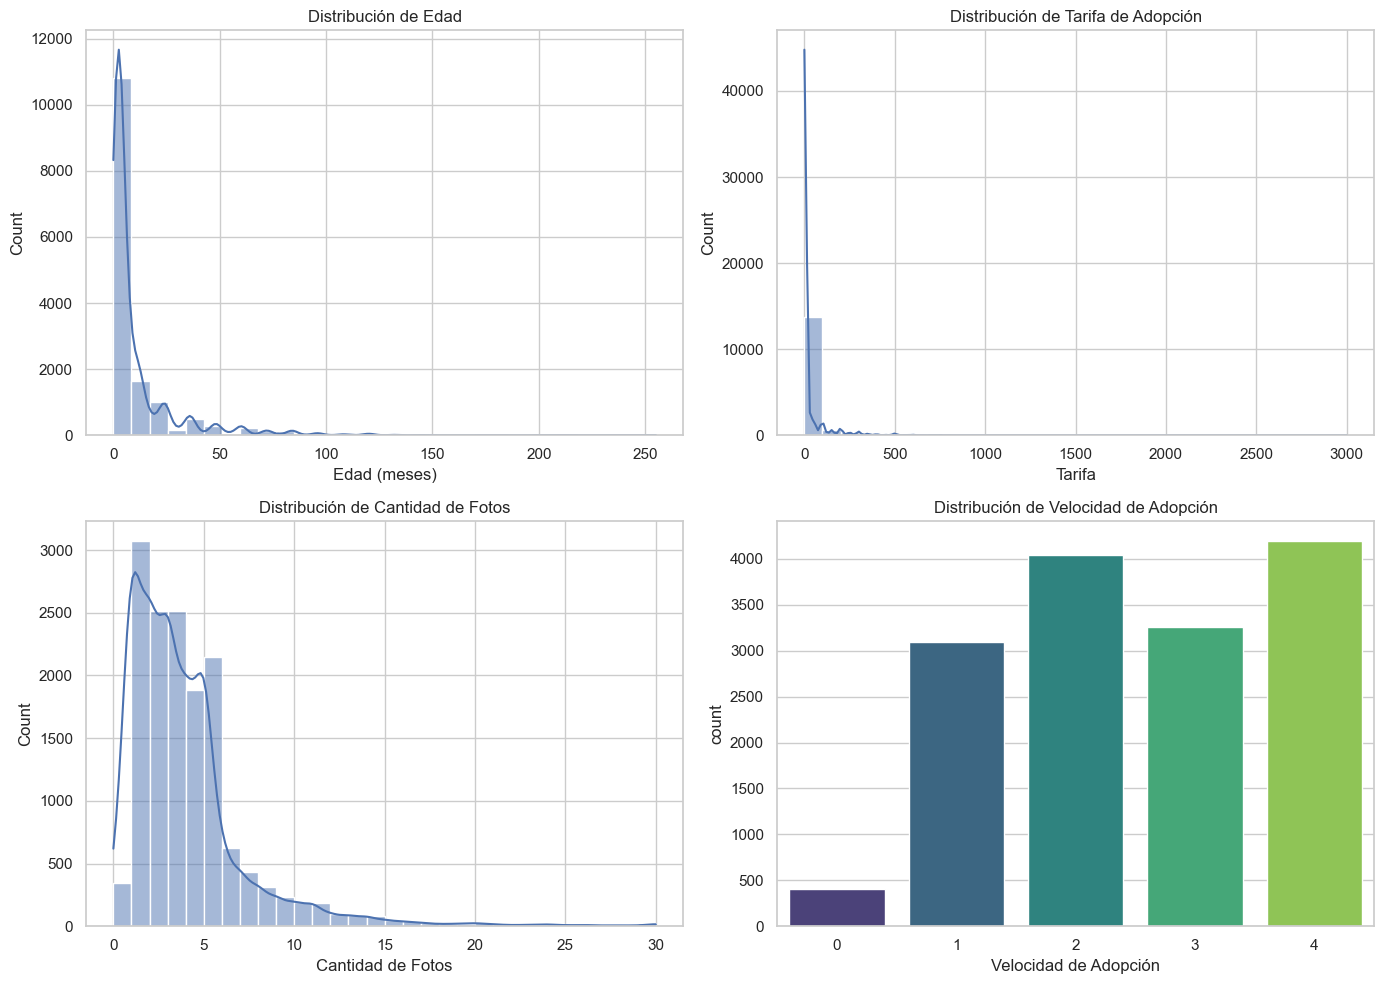

In [8]:
# Estadísticas descriptivas para variables categóricas
categorical_columns = ['Type', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'AdoptionSpeed']
print(train[categorical_columns].describe(include='all'))

# Configurar el estilo de los gráficos
sns.set(style="whitegrid")

# Crear gráficos de distribución
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de la edad
sns.histplot(train['Age'], bins=30, kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Distribución de Edad')
axs[0, 0].set_xlabel('Edad (meses)')

# Distribución de la tarifa de adopción
sns.histplot(train['Fee'], bins=30, kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Distribución de Tarifa de Adopción')
axs[0, 1].set_xlabel('Tarifa')

# Distribución de la cantidad de fotos
sns.histplot(train['PhotoAmt'], bins=30, kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Distribución de Cantidad de Fotos')
axs[1, 0].set_xlabel('Cantidad de Fotos')

# Distribución de la velocidad de adopción
sns.countplot(x='AdoptionSpeed', data=train, palette='viridis', ax=axs[1, 1])
axs[1, 1].set_title('Distribución de Velocidad de Adopción')
axs[1, 1].set_xlabel('Velocidad de Adopción')

plt.tight_layout()
plt.show()

In [11]:
# Instalar langdetect
# Instalar las librerías necesarias
!pip install langdetect
!pip install textblob


import re
from textblob import TextBlob
from langdetect import detect



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.3/626.3 kB 9.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.5/278.5 kB 2.4 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.9/97.9 kB 10.8 MB/s eta 0:00:00


/var/folders/l7/l93x40d92cvcv2gjmhtlx83m0000gn/T/ipykernel_93149/766559938.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='desc_language', data=train, ax=axs[1, 0], palette='viridis')


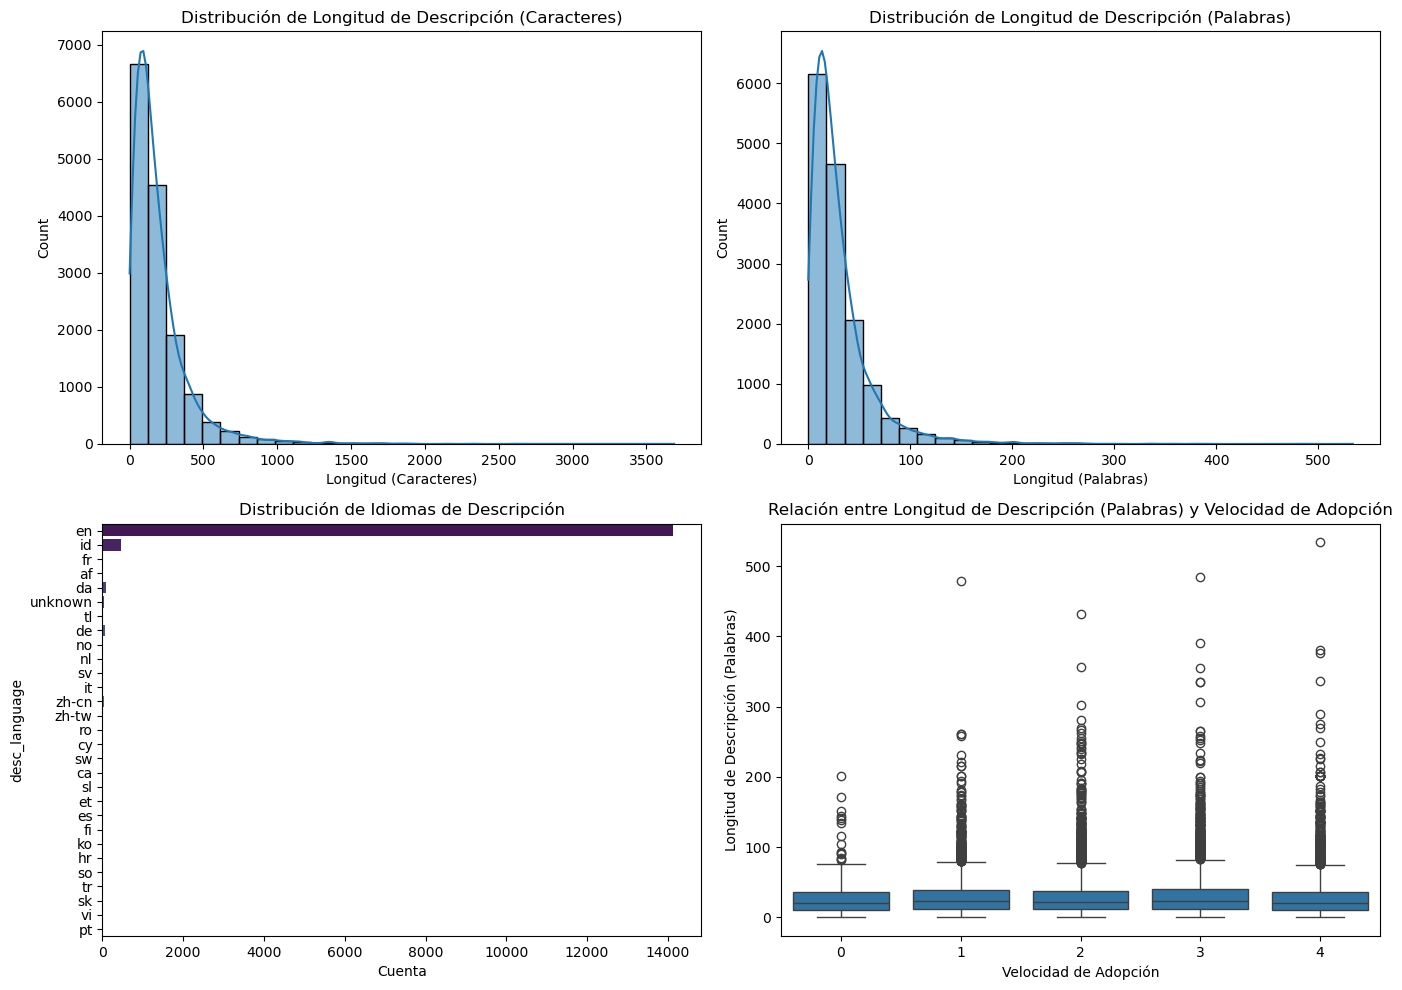

       PetID  AdoptionSpeed  desc_length_char  desc_length_word desc_language
0  86e1089a3              2               209                31            en
1  6296e909a              0                71                10            en
2  3422e4906              3               249                34            en
3  5842f1ff5              2                98                15            en
4  850a43f90              2               186                30            en


In [4]:
#Agregar Librería para detectar idioma
from langdetect import detect
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stopwords



# Función para limpiar y preprocesar el texto
def clean_text(text):
    text = re.sub(r'\d+', '', text)  # Eliminar números
    text = re.sub(r'\W+', ' ', text)  # Eliminar caracteres especiales
    text = text.lower()  # Convertir a minúsculas
    text = ' '.join([word for word in text.split() if word not in stopwords])  # Eliminar stopwords
    return text

# Aplicar la función de limpieza
train['cleaned_description'] = train['Description'].fillna('').apply(clean_text)

# Extraer longitud de la descripción
train['desc_length_char'] = train['cleaned_description'].apply(len)
train['desc_length_word'] = train['cleaned_description'].apply(lambda x: len(x.split()))

# Detectar idioma de la descripción
def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'

train['desc_language'] = train['Description'].fillna('').apply(detect_language)

# Visualizar la distribución de las nuevas características
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Longitud de la descripción (caracteres)
sns.histplot(train['desc_length_char'], bins=30, kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Distribución de Longitud de Descripción (Caracteres)')
axs[0, 0].set_xlabel('Longitud (Caracteres)')

# Longitud de la descripción (palabras)
sns.histplot(train['desc_length_word'], bins=30, kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Distribución de Longitud de Descripción (Palabras)')
axs[0, 1].set_xlabel('Longitud (Palabras)')

# Distribución del idioma de la descripción
sns.countplot(y='desc_language', data=train, ax=axs[1, 0], palette='viridis')
axs[1, 0].set_title('Distribución de Idiomas de Descripción')
axs[1, 0].set_xlabel('Cuenta')

# Relación entre longitud de la descripción y velocidad de adopción
sns.boxplot(x='AdoptionSpeed', y='desc_length_word', data=train, ax=axs[1, 1])
axs[1, 1].set_title('Relación entre Longitud de Descripción (Palabras) y Velocidad de Adopción')
axs[1, 1].set_xlabel('Velocidad de Adopción')
axs[1, 1].set_ylabel('Longitud de Descripción (Palabras)')

plt.tight_layout()
plt.show()

# Mostrar algunas filas del dataframe con las nuevas columnas
print(train[['PetID', 'AdoptionSpeed', 'desc_length_char', 'desc_length_word', 'desc_language']].head())


In [15]:
# Instalar las librerías necesarias
!pip install langdetect textblob

# Importar las librerías necesarias

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import re
from textblob import TextBlob
from langdetect import detect


# Preparación de los datos
train = train.fillna('')

# Convertir variables categóricas a dummy variables
categorical_columns = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']
train = pd.get_dummies(train, columns=categorical_columns)

# Función para limpiar y preprocesar el texto
def clean_text(text):
    text = re.sub(r'\d+', '', text)  # Eliminar números
    text = re.sub(r'\W+', ' ', text)  # Eliminar caracteres especiales
    text = text.lower()  # Convertir a minúsculas
    return text

# Aplicar la función de limpieza
train['cleaned_description'] = train['Description'].apply(lambda x: clean_text(str(x)))

# Detectar el idioma y traducir a inglés si es necesario
def translate_to_english(text):
    try:
        lang = detect(text)
        if lang != 'en':
            return str(TextBlob(text).translate(to='en'))
        else:
            return text
    except:
        return text

train['translated_description'] = train['cleaned_description'].apply(lambda x: translate_to_english(x))

# Características adicionales del campo "Description"
train['desc_length_char'] = train['translated_description'].apply(len)
train['desc_length_word'] = train['translated_description'].apply(lambda x: len(x.split()))

# Análisis de sentimiento
train['sentiment_polarity'] = train['translated_description'].apply(lambda x: TextBlob(x).sentiment.polarity)
train['sentiment_subjectivity'] = train['translated_description'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Presencia de palabras clave relacionadas con el comportamiento
keywords = ['friendly', 'playful', 'calm', 'aggressive', 'affectionate', 'timid', 'energetic']
for keyword in keywords:
    train[f'keyword_{keyword}'] = train['translated_description'].apply(lambda x: 1 if keyword in x else 0)

# Variable objetivo y características
X = train.drop(columns=['AdoptionSpeed', 'Description', 'cleaned_description', 'translated_description', 'PetID', 'Name', 'RescuerID'])
y = train['AdoptionSpeed']

# Binarizar la variable objetivo para enfocarse en la clase 0
y_binary = (y == 0).astype(int)

# Separar en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Entrenar un modelo de Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Obtener importancias de las características
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)

# Visualización de las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Características Importantes para Predicción de Adopción Rápida (Clase 0)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

# Mostrar las principales características
print(feature_importance_df)


ValueError: could not convert string to float: 'en'

In [1]:


# Preparación de los datos
train = train.fillna('')

# Convertir variables categóricas a dummy variables (si no se han convertido ya)
# categorical_columns = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']
# train = pd.get_dummies(train, columns=categorical_columns)

# Función para limpiar y preprocesar el texto
def clean_text(text):
    text = re.sub(r'\d+', '', text)  # Eliminar números
    text = re.sub(r'\W+', ' ', text)  # Eliminar caracteres especiales
    text = text.lower()  # Convertir a minúsculas
    return text

# Aplicar la función de limpieza
train['cleaned_description'] = train['Description'].apply(lambda x: clean_text(str(x)))

# Detectar el idioma y traducir a inglés si es necesario
def translate_to_english(text):
    try:
        lang = detect(text)
        if lang != 'en':
            return str(TextBlob(text).translate(to='en'))
        else:
            return text
    except:
        return text

train['translated_description'] = train['cleaned_description'].apply(lambda x: translate_to_english(x))

# Características adicionales del campo "Description"
train['desc_length_char'] = train['translated_description'].apply(len)
train['desc_length_word'] = train['translated_description'].apply(lambda x: len(x.split()))

# Análisis de sentimiento
train['sentiment_polarity'] = train['translated_description'].apply(lambda x: TextBlob(x).sentiment.polarity)
train['sentiment_subjectivity'] = train['translated_description'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Presencia de palabras clave relacionadas con el comportamiento
keywords = ['friendly', 'playful', 'calm', 'aggressive', 'affectionate', 'timid', 'energetic']
for keyword in keywords:
    train[f'keyword_{keyword}'] = train['translated_description'].apply(lambda x: 1 if keyword in x else 0)

# Eliminar columnas no necesarias
columns_to_drop = ['PetID', 'Name', 'RescuerID', 'Description', 'cleaned_description', 'translated_description']
X = train.drop(columns=columns_to_drop + ['AdoptionSpeed'])
y = train['AdoptionSpeed']

# Binarizar la variable objetivo para enfocarse en la clase 0
y_binary = (y == 0).astype(int)

# Separar en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Entrenar un modelo de Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Obtener importancias de las características
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)

# Visualización de las importancias de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Características Importantes para Predicción de Adopción Rápida (Clase 0)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

# Mostrar las principales características
print(feature_importance_df)


NameError: name 'train' is not defined

In [17]:
# Aplicar la función de limpieza
train['cleaned_description'] = train['Description'].apply(lambda x: clean_text(str(x)))

# Detectar el idioma y traducir a inglés si es necesario
def translate_to_english(text):
    try:
        lang = detect(text)
        if lang != 'en':
            return str(TextBlob(text).translate(to='en'))
        else:
            return text
    except:
        return text

train['translated_description'] = train['cleaned_description'].apply(lambda x: translate_to_english(x))

# Características adicionales del campo "Description"
train['desc_length_char'] = train['translated_description'].apply(len)
train['desc_length_word'] = train['translated_description'].apply(lambda x: len(x.split()))

# Análisis de sentimiento
train['sentiment_polarity'] = train['translated_description'].apply(lambda x: TextBlob(x).sentiment.polarity)
train['sentiment_subjectivity'] = train['translated_description'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Presencia de palabras clave relacionadas con el comportamiento
keywords = ['friendly', 'playful', 'calm', 'aggressive', 'affectionate', 'timid', 'energetic']
for keyword in keywords:
    train[f'keyword_{keyword}'] = train['translated_description'].apply(lambda x: 1 if keyword in x else 0)


In [18]:
# Mostrar el resultado en el DataFrame
print(train[['Description', 'cleaned_description', 'translated_description',
             'desc_length_char', 'desc_length_word',
             'sentiment_polarity', 'sentiment_subjectivity',
             'keyword_friendly', 'keyword_playful', 'keyword_calm',
             'keyword_aggressive', 'keyword_affectionate', 'keyword_timid', 'keyword_energetic']].head())

                                         Description  \
0  Nibble is a 3+ month old ball of cuteness. He ...   
1  I just found it alone yesterday near my apartm...   
2  Their pregnant mother was dumped by her irresp...   
3  Good guard dog, very alert, active, obedience ...   
4  This handsome yet cute boy is up for adoption....   

                                 cleaned_description  \
0  nibble is a month old ball of cuteness he is e...   
1  i just found it alone yesterday near my apartm...   
2  their pregnant mother was dumped by her irresp...   
3  good guard dog very alert active obedience wai...   
4  this handsome yet cute boy is up for adoption ...   

                              translated_description  desc_length_char  \
0  nibble is a month old ball of cuteness he is e...               351   
1  i just found it alone yesterday near my apartm...               117   
2  their pregnant mother was dumped by her irresp...               385   
3  good guard dog very alert a

In [4]:
train.head() 

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


### Data Fields

* PetID - Unique hash ID of pet profile
* AdoptionSpeed - Categorical speed of adoption. Lower is faster. This is the value to predict. See below section for more info.
* Type - Type of animal (1 = Dog, 2 = Cat)
* Name - Name of pet (Empty if not named)
* Age - Age of pet when listed, in months
* Breed1 - Primary breed of pet (Refer to BreedLabels dictionary)
* Breed2 - Secondary breed of pet, if pet is of mixed breed (Refer to BreedLabels dictionary)
* Gender - Gender of pet (1 = Male, 2 = Female, 3 = Mixed, if profile represents group of pets)
* Color1 - Color 1 of pet (Refer to ColorLabels dictionary)
* Color2 - Color 2 of pet (Refer to ColorLabels dictionary)
* Color3 - Color 3 of pet (Refer to ColorLabels dictionary)
* MaturitySize - Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)
* FurLength - Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)
* Vaccinated - Pet has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)
* Dewormed - Pet has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)
* Sterilized - Pet has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)
* Health - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)
* Quantity - Number of pets represented in profile
* Fee - Adoption fee (0 = Free)
* State - State location in Malaysia (Refer to StateLabels dictionary)
* RescuerID - Unique hash ID of rescuer
* VideoAmt - Total uploaded videos for this pet
* PhotoAmt - Total uploaded photos for this pet
* Description - Profile write-up for this pet. The primary language used is English, with some in Malay or Chinese.

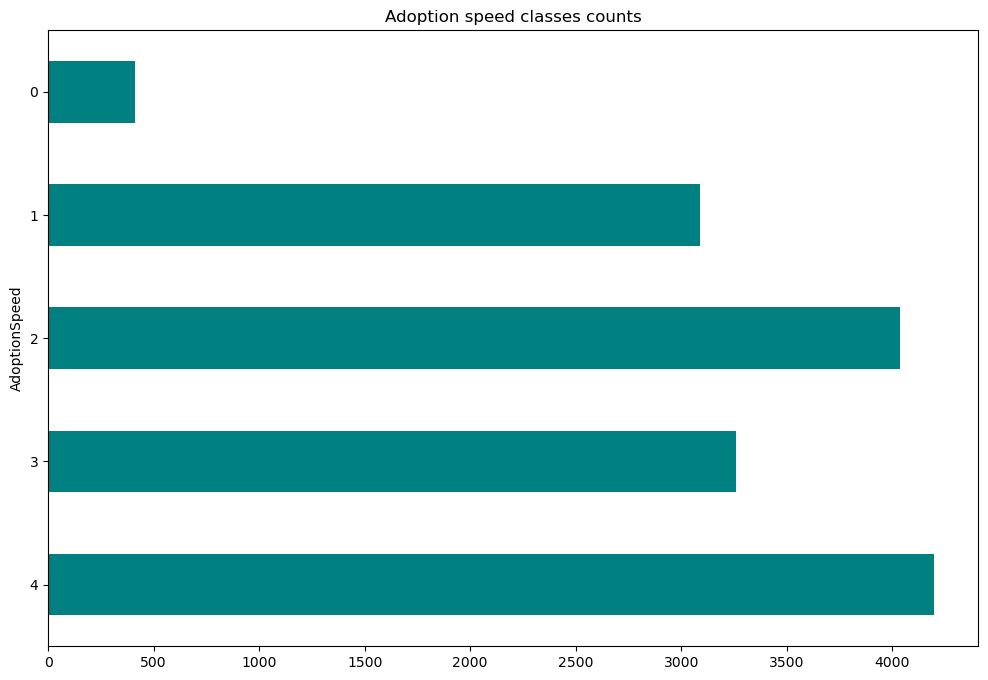

In [5]:
train['AdoptionSpeed'].value_counts().sort_index(ascending = False).plot(kind='barh', color='teal');
plt.title('Adoption speed classes counts');

### Target: AdoptionSpeed

The value is determined by how quickly, if at all, a pet is adopted. The values are determined in the following way:

* 0 - Pet was adopted on the same day as it was listed.
* 1 - Pet was adopted between 1 and 7 days (1st week) after being listed.
* 2 - Pet was adopted between 8 and 30 days (1st month) after being listed.
* 3 - Pet was adopted between 31 and 90 days (2nd & 3rd month) after being listed.
* 4 - No adoption after 100 days of being listed. (There are no pets in this dataset that waited between 90 and 100 days).

In [2]:
# Mapeamos el Tipo de Mascota
train['Type'] = train['Type'].apply(lambda x: 'Dog' if x == 1 else 'Cat')

NameError: name 'train' is not defined

In [1]:
sns.countplot(x='Type', data=train);
plt.title('Number of cats and dogs');

NameError: name 'sns' is not defined

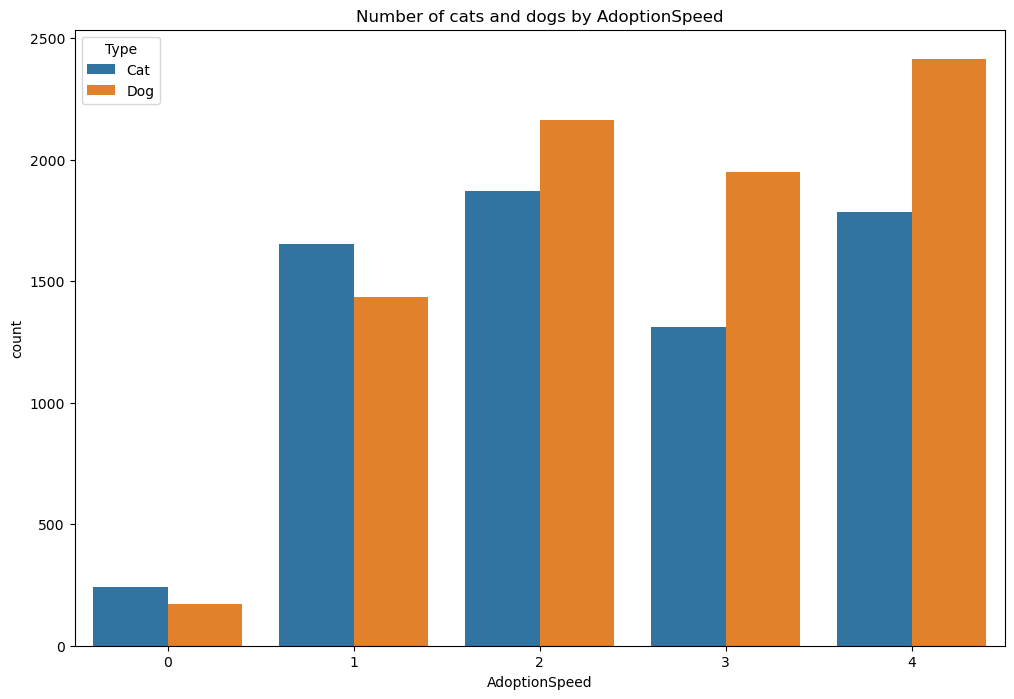

In [10]:
sns.countplot(x='AdoptionSpeed', data=train, hue='Type');
plt.title('Number of cats and dogs by AdoptionSpeed');

In [11]:
train.Name.value_counts()

Name
Baby                      66
Lucky                     64
No Name                   54
Brownie                   54
Mimi                      52
                          ..
Maroo                      1
4 PUPPIES FOR ADOPTION     1
Trish                      1
Lab Mix Puppy 2            1
Fili                       1
Name: count, Length: 9059, dtype: int64

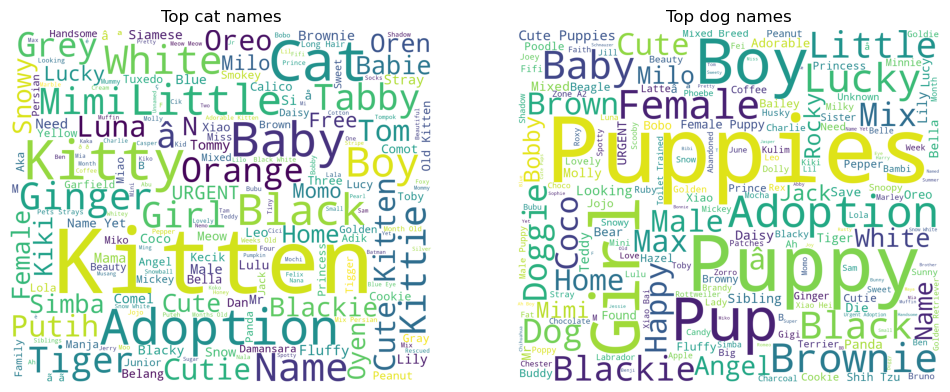

In [12]:
plt.subplot(1, 2, 1)
text_cat = ' '.join(train.loc[train['Type'] == 'Cat', 'Name'].fillna('').values)
wordcloud = WordCloud(max_font_size=None, background_color='white',
                      width=1200, height=1000).generate(text_cat)
plt.imshow(wordcloud)
plt.title('Top cat names')
plt.axis("off")

plt.subplot(1, 2, 2)
text_dog = ' '.join(train.loc[train['Type'] == 'Dog', 'Name'].fillna('').values)
wordcloud = WordCloud(max_font_size=None, background_color='white',
                      width=1200, height=1000).generate(text_dog)
plt.imshow(wordcloud)
plt.title('Top dog names')
plt.axis("off")

plt.show()

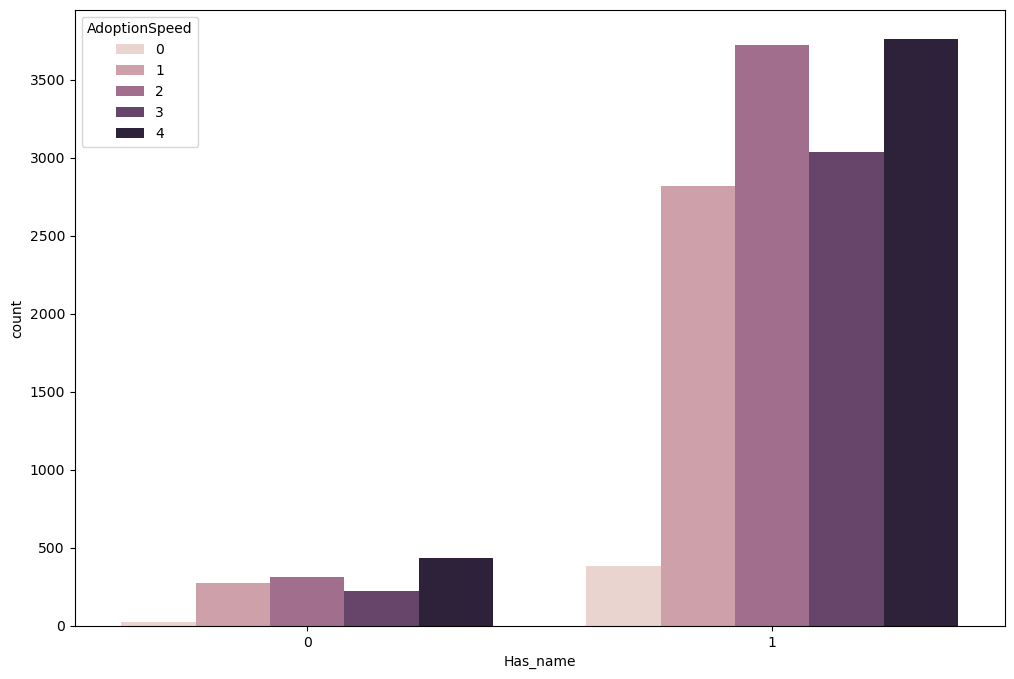

In [15]:
train['Name'] = train['Name'].fillna('Unnamed')
train['Has_name'] = 1
train.loc[train['Name'] == 'Unnamed', 'Has_name'] = 0

sns.countplot(x='Has_name', data=train, hue='AdoptionSpeed');

/var/folders/l7/l93x40d92cvcv2gjmhtlx83m0000gn/T/ipykernel_23811/1177881723.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Has_description', data=train, palette='viridis', ax=axes[1])


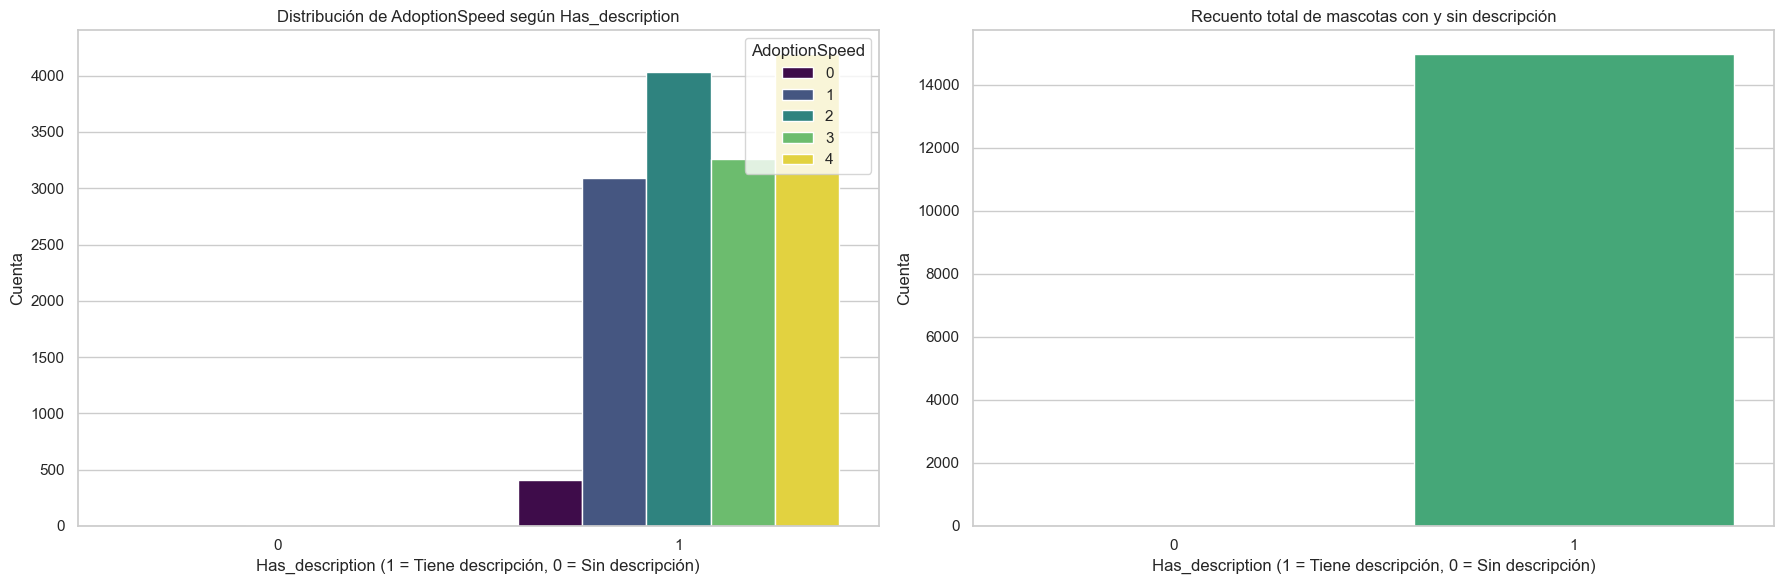

In [5]:

# Crear la columna 'Has_description' para indicar si hay descripción
train['Has_description'] = train['Description'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1)

# Configurar el estilo de los gráficos
sns.set(style="whitegrid")

# Crear un subplot con dos gráficos separados
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Gráfico 1: Distribución de AdoptionSpeed según Has_description
sns.countplot(x='Has_description', data=train, hue='AdoptionSpeed', palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de AdoptionSpeed según Has_description')
axes[0].set_xlabel('Has_description (1 = Tiene descripción, 0 = Sin descripción)')
axes[0].set_ylabel('Cuenta')
axes[0].legend(title='AdoptionSpeed', loc='upper right')

# Gráfico 2: Recuento total de mascotas con y sin descripción
sns.countplot(x='Has_description', data=train, palette='viridis', ax=axes[1])
axes[1].set_title('Recuento total de mascotas con y sin descripción')
axes[1].set_xlabel('Has_description (1 = Tiene descripción, 0 = Sin descripción)')
axes[1].set_ylabel('Cuenta')

# Mostrar los gráficos
plt.tight_layout()
plt.show()


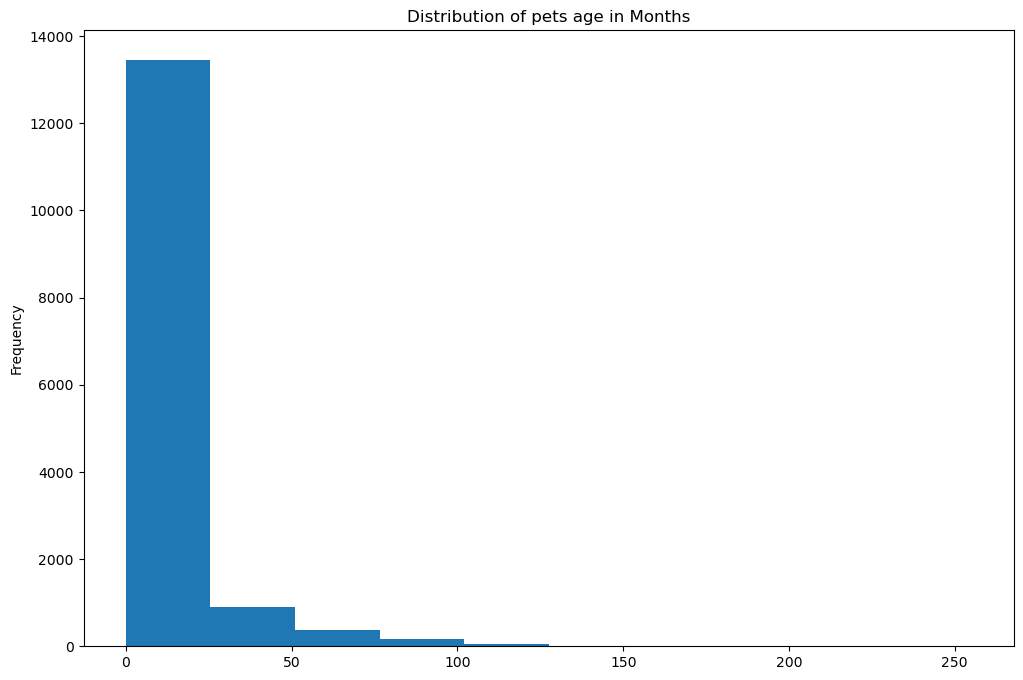

In [13]:
train['Age'].plot(kind='hist')
plt.title('Distribution of pets age in Months');

## Tareas a Realizar

#### Pre-procesamiento:

* Chequear Nulos y Decidir si Imputar o Descartar
* Chequear Variables Categóricas y convertirlas en Numéricas
* Estandarizar o Normalizar

#### Ideas para EDA:

* Analizar la Raza de las Mascotas
* Analizar el Género
* Analizar los 3 Colores Informados para cada Mascota
* Estudiar las variables de Salud: Vacunación, Esterilización, Desparacitación
* Entender el impacto del Fee cobrado
* Estudiar las Regiones Geográficas disponibles
* Analizar el impacto de tener Fotos y/o Videos

Todos estos análisis pueden hacerse en función de la Especie (Gato/Perro) y respecto al Target


#### Análisis del Texto Libre de la Descripción:

* Tokenizar Palabras más frecuentes
* Limpiar palabras
* Bag of Words / TF-IDF



In [14]:
##Describir el dataset 
print(train.describe())


                Age        Breed1        Breed2        Gender        Color1  \
count  14993.000000  14993.000000  14993.000000  14993.000000  14993.000000   
mean      10.452078    265.272594     74.009738      1.776162      2.234176   
std       18.155790     60.056818    123.011575      0.681592      1.745225   
min        0.000000      0.000000      0.000000      1.000000      1.000000   
25%        2.000000    265.000000      0.000000      1.000000      1.000000   
50%        3.000000    266.000000      0.000000      2.000000      2.000000   
75%       12.000000    307.000000    179.000000      2.000000      3.000000   
max      255.000000    307.000000    307.000000      3.000000      7.000000   

             Color2        Color3  MaturitySize     FurLength    Vaccinated  \
count  14993.000000  14993.000000  14993.000000  14993.000000  14993.000000   
mean       3.222837      1.882012      1.862002      1.467485      1.731208   
std        2.742562      2.984086      0.547959    

In [22]:
nulos=train.isnull().sum()  ##['Age'].count() # chequeamos los nulos ahora

##null_counts = train.isnull().sum()
print(nulos)


Type                0
Name             1265
Age                 0
Breed1              0
Breed2              0
Gender              0
Color1              0
Color2              0
Color3              0
MaturitySize        0
FurLength           0
Vaccinated          0
Dewormed            0
Sterilized          0
Health              0
Quantity            0
Fee                 0
State               0
RescuerID           0
VideoAmt            0
Description        13
PetID               0
PhotoAmt            0
AdoptionSpeed       0
dtype: int64


   Type         Name  Age  Breed1  Breed2  Gender  Color1  Color2  Color3  \
0     2       Nibble    3     299       0       1       1       7       0   
1     2  No Name Yet    1     265       0       1       1       2       0   
2     1       Brisco    1     307       0       1       2       7       0   
3     1         Miko    4     307       0       2       1       2       0   
4     1       Hunter    1     307       0       1       1       0       0   

   MaturitySize  FurLength  Vaccinated  Dewormed  Sterilized  Health  \
0             1          1           2         2           2       1   
1             2          2           3         3           3       1   
2             2          2           1         1           2       1   
3             2          1           1         1           2       1   
4             2          1           2         2           2       1   

   Quantity  Fee  State                         RescuerID  VideoAmt  \
0         1  100  41326  8480853f

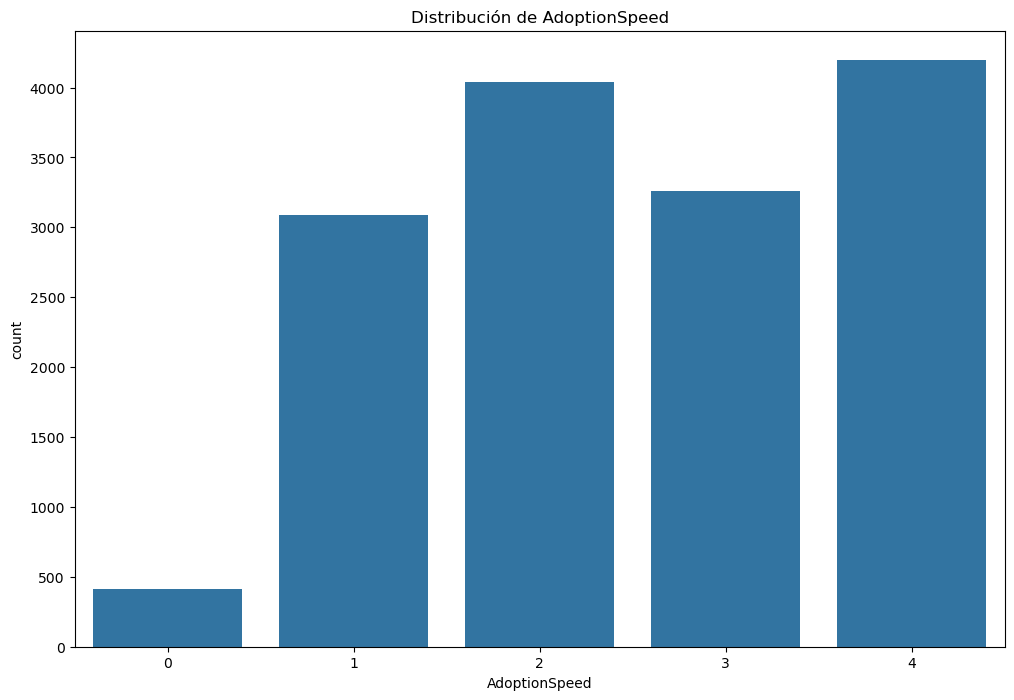

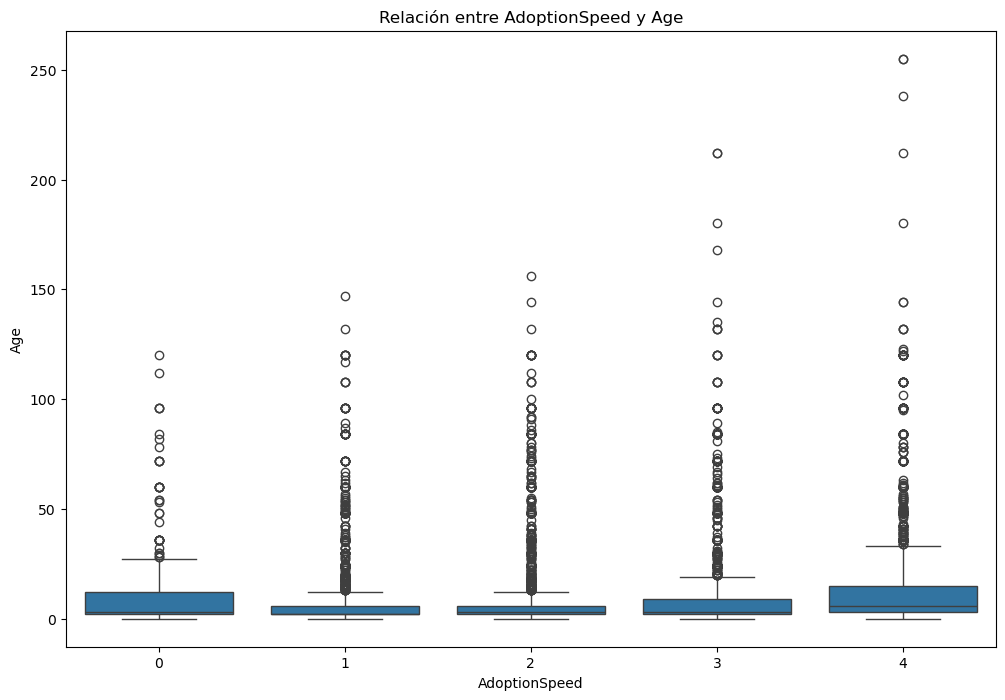

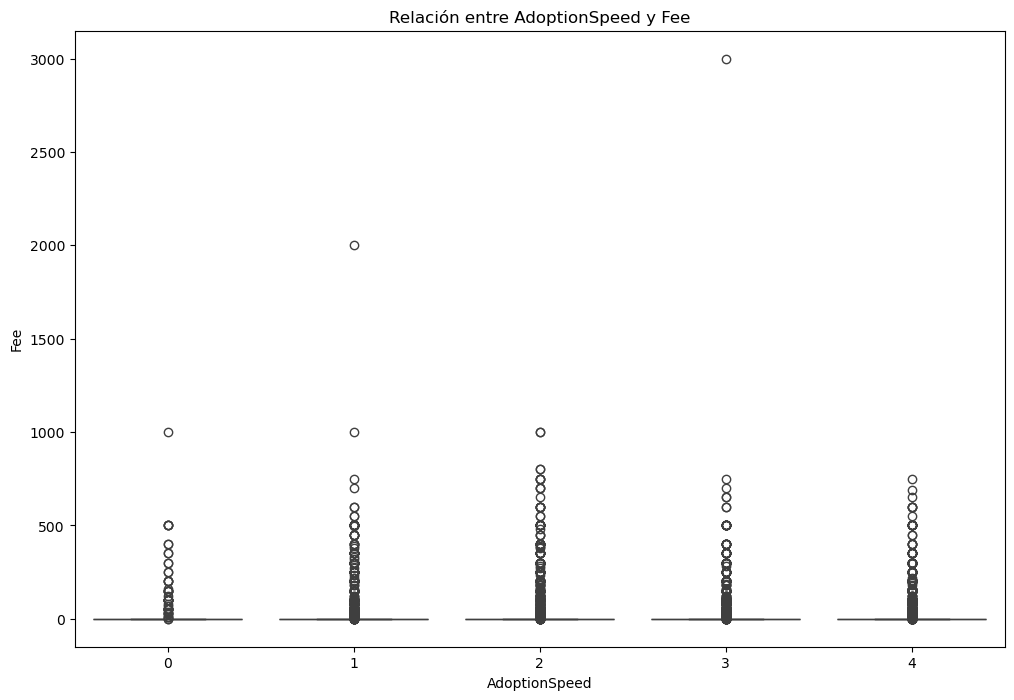

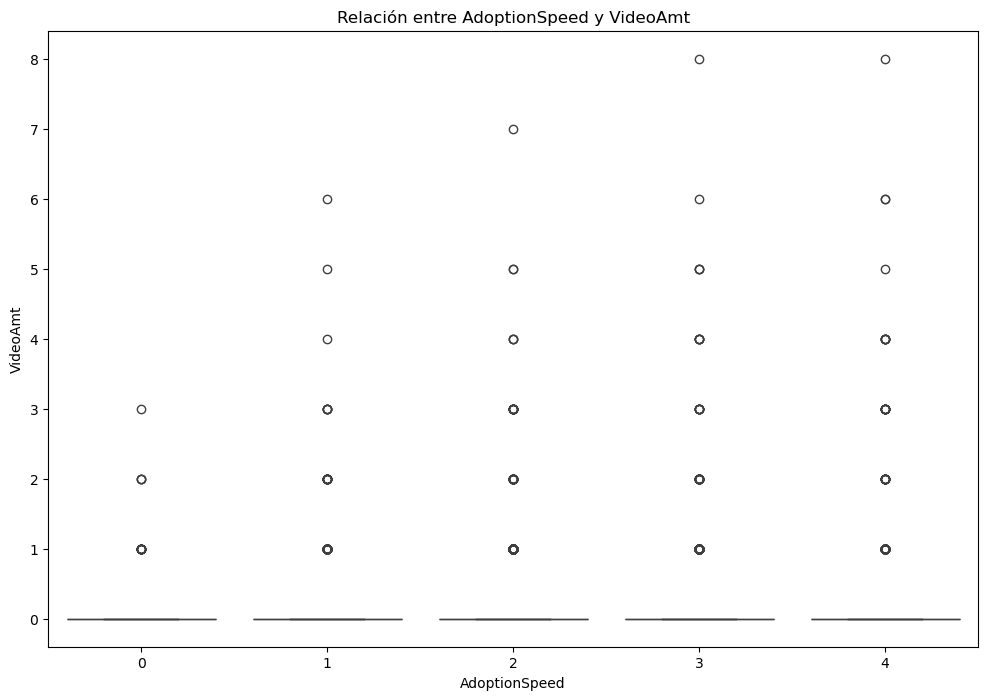

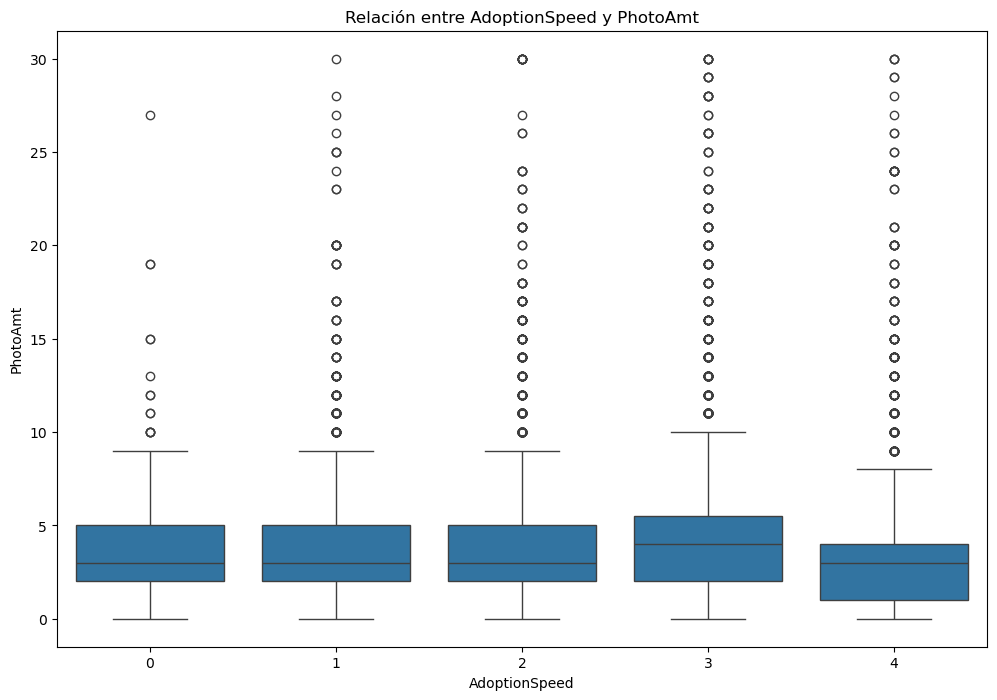

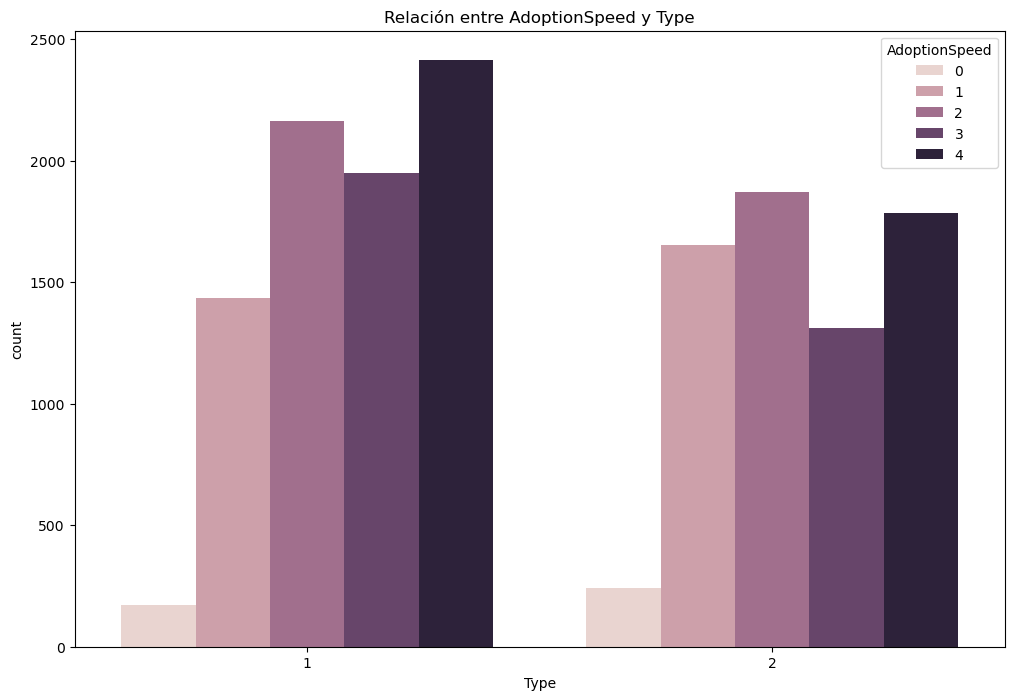

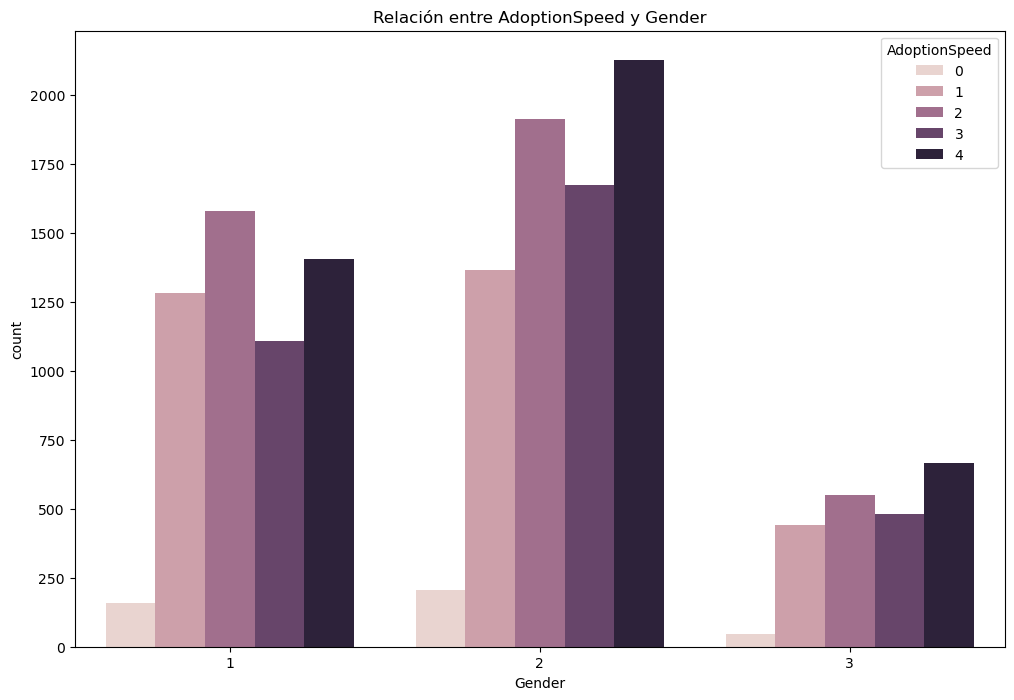

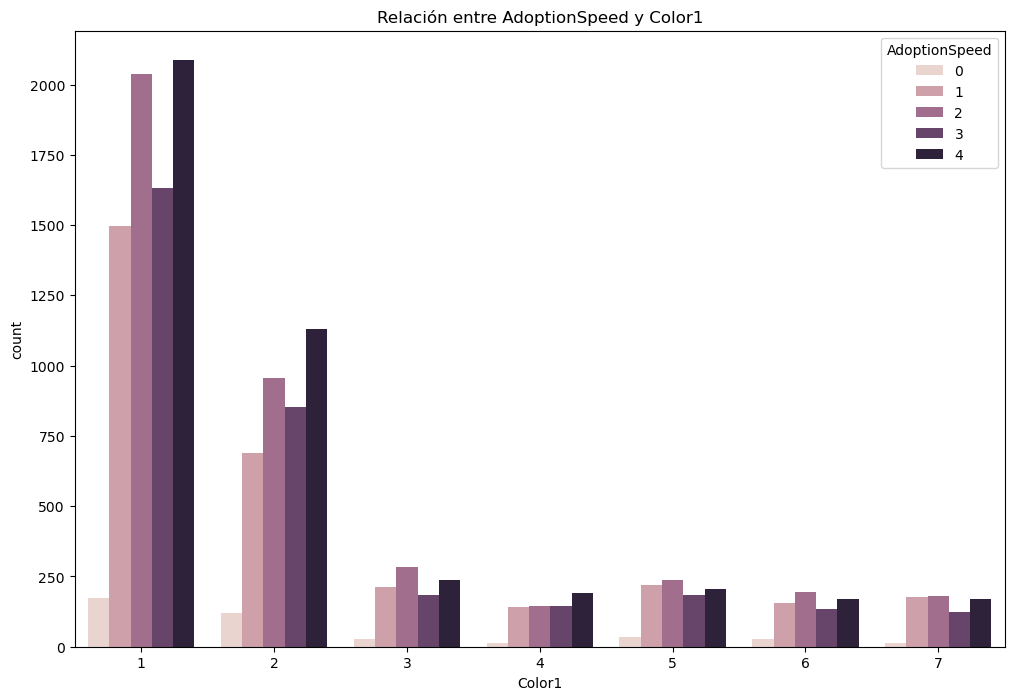

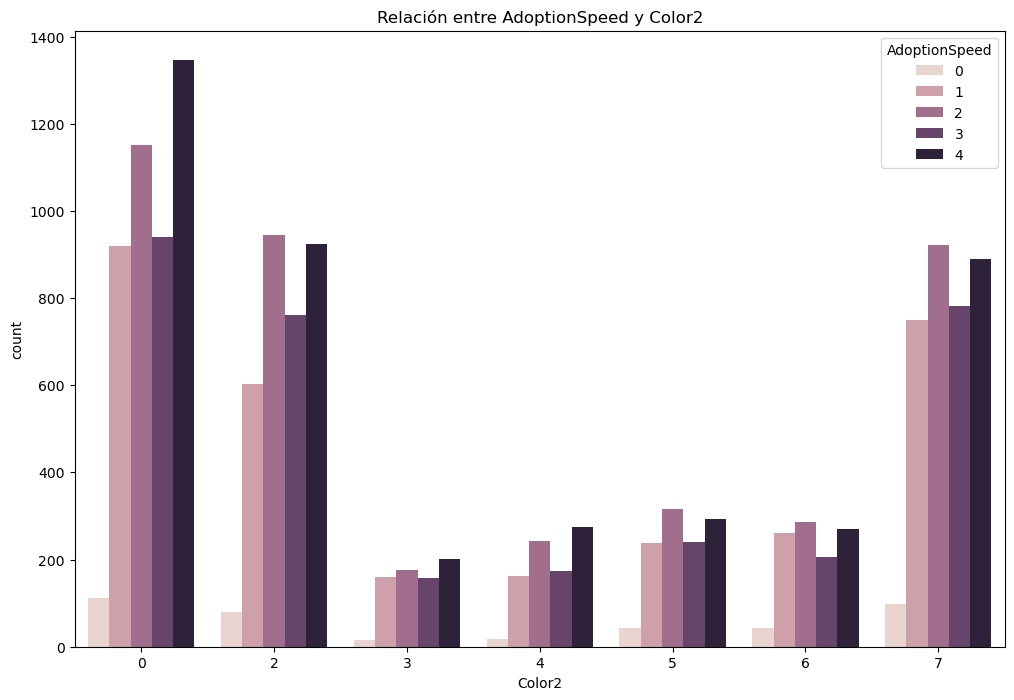

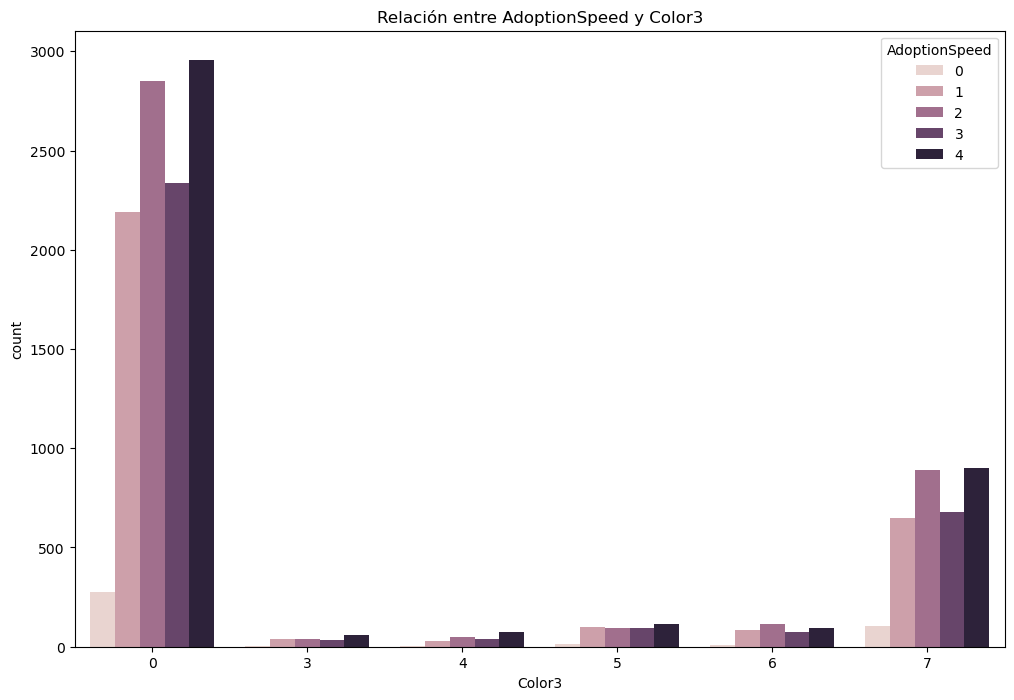

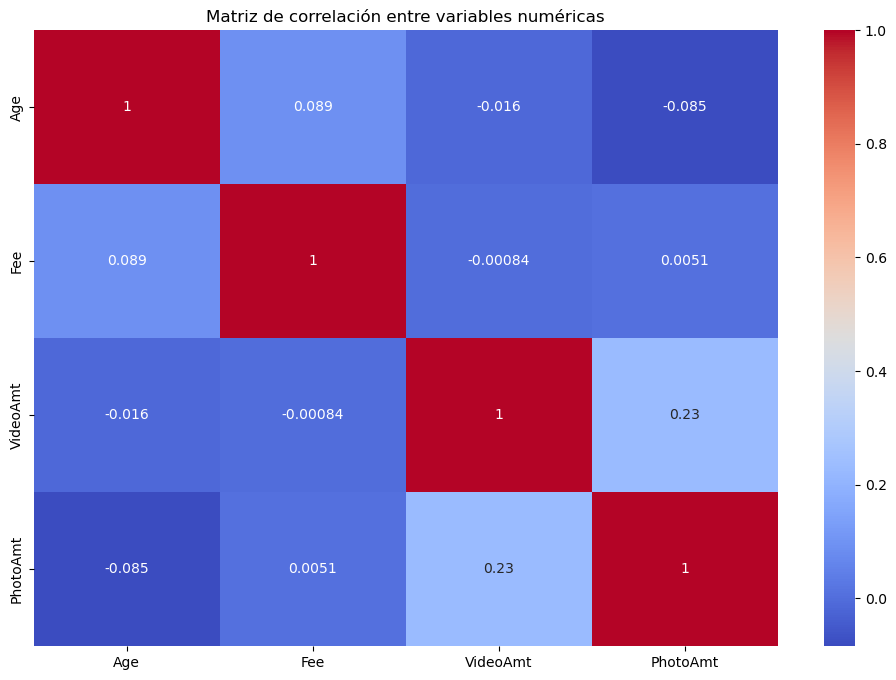

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Visualización rápida de los primeros registros y resumen estadístico
print(train.head())
print(train.describe())

# Análisis exploratorio de datos (EDA)
# 1. Distribución de AdoptionSpeed (variable objetivo)
sns.countplot(x='AdoptionSpeed', data=train)
plt.title('Distribución de AdoptionSpeed')
plt.show()

# 2. Relaciones entre variables numéricas y AdoptionSpeed
numeric_features = ['Age', 'Fee', 'VideoAmt', 'PhotoAmt']
for feature in numeric_features:
    sns.boxplot(x='AdoptionSpeed', y=feature, data=train)
    plt.title(f'Relación entre AdoptionSpeed y {feature}')
    plt.show()

# 3. Relaciones entre variables categóricas y AdoptionSpeed
categorical_features = ['Type', 'Gender', 'Color1', 'Color2', 'Color3']
for feature in categorical_features:
    sns.countplot(x=feature, hue='AdoptionSpeed', data=train)
    plt.title(f'Relación entre AdoptionSpeed y {feature}')
    plt.show()

# 4. Correlación entre variables numéricas
correlation_matrix = train[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

# Selección de características utilizando ANOVA (f_classif)
# 



In [8]:
filtered_data = train[train['Quantity'] > 1]['Age']

# Mostrar los valores de edad
print("Valores de edad para Quantity > 1:")
print(filtered_data)


Valores de edad para Quantity > 1:
7         0
13        2
19        1
21        3
22        0
         ..
14976    84
14982     2
14988     2
14989    60
14990     2
Name: Age, Length: 3428, dtype: int64


In [9]:
# Filtrar los registros donde Quantity sea mayor a 1 y seleccionar las edades
filtered_data = train[train['Quantity'] > 1][['PetID', 'Age']]

# Presentar los resultados en formato de tabla
print("Registros donde Quantity > 1 - Edades:")
print(filtered_data)

Registros donde Quantity > 1 - Edades:
           PetID  Age
7      97aa9eeac    0
13     4a9793dfb    2
19     b10e7605a    1
21     234a5a54c    3
22     1bc0f89d8    0
...          ...  ...
14976  98ae7d88d   84
14982  54b6c1d72    2
14988  dc0935a84    2
14989  a01ab5b30   60
14990  d981b6395    2

[3428 rows x 2 columns]


In [1]:
import pandas as pd

# Suponiendo que 'train' ya está cargado y es tu DataFrame
# Si no está cargado, asegúrate de cargarlo antes de ejecutar este código

# Filtrar los registros donde Quantity sea mayor a 1 y seleccionar las columnas Quantity y Age
filtered_data = train[train['Quantity'] > 1][['Quantity', 'Age' ,'Gender']]

# Presentar los resultados en formato de tabla
print("Registros donde Quantity > 1 - Quantity y Age y Gender")
print(filtered_data)


NameError: name 'train' is not defined

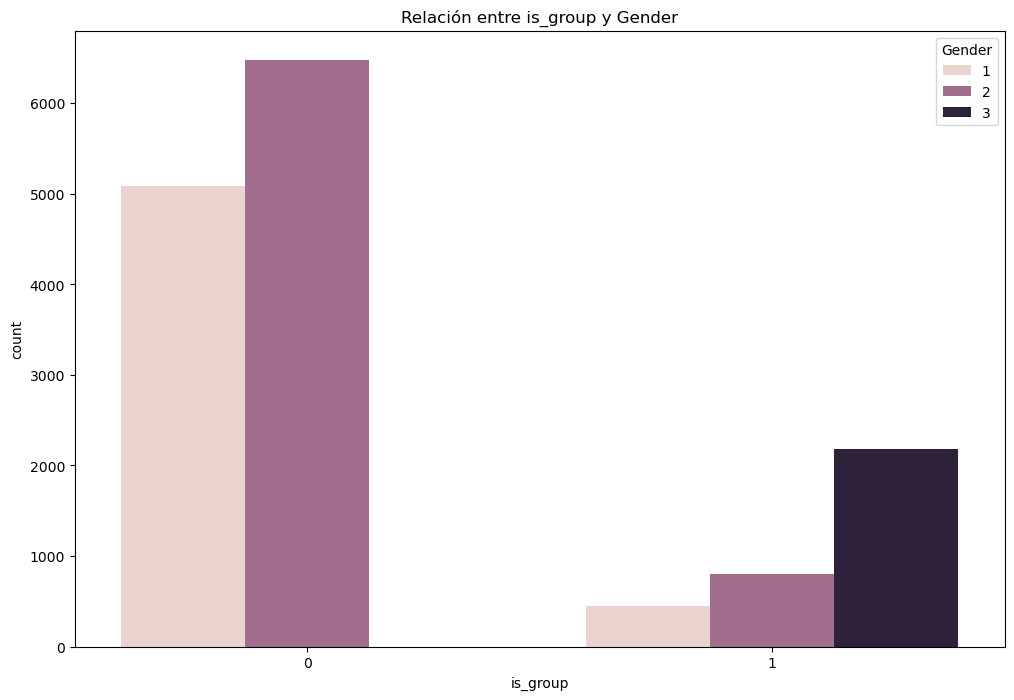

In [12]:
# Crear la columna is_group según la condición dada
train['is_group'] = train['Quantity'].apply(lambda x: 1 if x > 1 else 0)

# Graficar la relación entre is_group y Gender
sns.countplot(x='is_group', hue='Gender', data=train)
plt.title('Relación entre is_group y Gender')
plt.show()
